In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_1_CLL/notebooks/Post-hoc_Analysis


In [2]:
# Libraries
import numpy as np
import re
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
import networkx as nx
from adjustText import adjust_text
import openpyxl

import gc
import re
import random
import math

import stringdb
import string
import logging

import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.colors import Normalize, LinearSegmentedColormap

from scipy.cluster.hierarchy import linkage, leaves_list
import igraph as ig
import leidenalg


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, leaves_list

In [3]:
gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_go = pd.read_excel("./PASNet/Output/GO/sc1_weights.xlsx", index_col=0)
pt = pd.read_excel("./PASNet/Input/GO/pt_fixed.xlsx", index_col=0)

sc1_go.columns = pt.columns
sc1_go.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_go.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_go = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_go = df_go[df_go['Weight'] != 0]

gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_rest = pd.read_excel("./PASNet/Output/REST/sc1_weights.xlsx", index_col=0)
pt = pd.read_excel("./PASNet/Input/REST/pt_fixed.xlsx", index_col=0)

sc1_rest.columns = pt.columns
sc1_rest.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_rest.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_rest = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_rest = df_rest[df_rest['Weight'] != 0]

In [4]:
pasnet_genes_go = df_go['target'].unique()
print(len(pasnet_genes_go))

pasnet_genes_rest = df_rest['target'].unique()
print(len(pasnet_genes_rest))

297
269


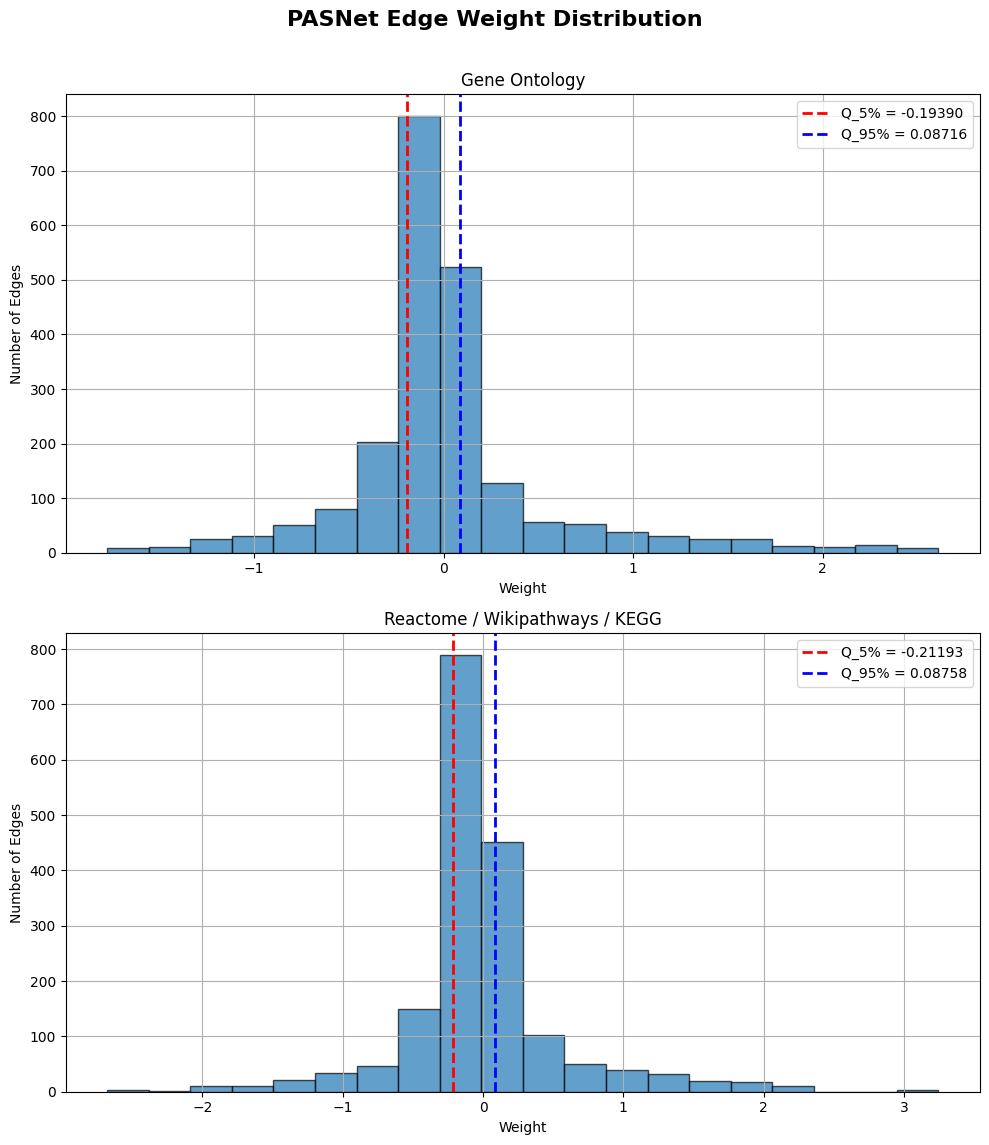

In [5]:
# Gene Ontology weights
weight_go = df_go['Weight']
q1_go = weight_go.quantile(0.25)
q3_go = weight_go.quantile(0.75)

# Reactome/Wikipathways/KEGG weights
weight_rest = df_rest['Weight']
q1_rest = weight_rest.quantile(0.25)
q3_rest = weight_rest.quantile(0.75)

# Create 2x1 subplot (stacked vertically)
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=False)

# Add overall figure title (multipanel title)
fig.suptitle('PASNet Edge Weight Distribution', fontsize=16, fontweight='bold', y=0.95)

# Plot Gene Ontology histogram
axes[0].hist(weight_go, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(x=q1_go, color='red', linestyle='--', linewidth=2, label=f'Q_5% = {q1_go:.5f}')
axes[0].axvline(x=q3_go, color='blue', linestyle='--', linewidth=2, label=f'Q_95% = {q3_go:.5f}')
axes[0].set_title('Gene Ontology')
axes[0].set_xlabel('Weight')
axes[0].set_ylabel('Number of Edges')
axes[0].grid(True)
axes[0].legend()

# Plot Reactome/Wikipathways/KEGG histogram
axes[1].hist(weight_rest, bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(x=q1_rest, color='red', linestyle='--', linewidth=2, label=f'Q_5% = {q1_rest:.5f}')
axes[1].axvline(x=q3_rest, color='blue', linestyle='--', linewidth=2, label=f'Q_95% = {q3_rest:.5f}')
axes[1].set_title('Reactome / Wikipathways / KEGG')
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Number of Edges')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space for suptitle
#plt.savefig('../../figures/edge_weight_distribution.png', dpi=300)  # Save as high-res PNG
plt.show()


In [6]:
df_go = df_go[(df_go['Weight'] > q3_go) | (df_go['Weight'] < q1_go)]
df_rest = df_rest[(df_rest['Weight'] > q3_rest) | (df_rest['Weight'] < q1_rest)]

In [7]:
shap_validation = pd.read_csv("./PASNet/Output/GO/feature_importance_table_icgc_validation.csv", index_col=0)
shap_validation_top20 = shap_validation.sort_values(by="Importance", ascending=False).head(20)

shap_testing = pd.read_csv("./PASNet/Output/GO/feature_importance_table_bcmo_testing.csv", index_col=0)
shap_testing_top20 = shap_testing.sort_values(by="Importance", ascending=False).head(20)

combined_df = pd.concat([shap_validation_top20, shap_testing_top20], axis=0)
combined_df = combined_df.sort_values(by="Importance", ascending=False)
combined_df_go = combined_df[~combined_df.index.duplicated(keep='first')]

shap_validation = pd.read_csv("./PASNet/Output/REST/feature_importance_table_icgc_validation.csv", index_col=0)
shap_validation_top20 = shap_validation.sort_values(by="Importance", ascending=False).head(20)

shap_testing = pd.read_csv("./PASNet/Output/REST/feature_importance_table_bcmo_testing.csv", index_col=0)
shap_testing_top20 = shap_testing.sort_values(by="Importance", ascending=False).head(20)

combined_df = pd.concat([shap_validation_top20, shap_testing_top20], axis=0)
combined_df = combined_df.sort_values(by="Importance", ascending=False)
combined_df_rest = combined_df[~combined_df.index.duplicated(keep='first')]

In [8]:
# Step 1: Get the feature names (index) from both DataFrames
features_rest = combined_df_rest.index
features_go = combined_df_go.index

# Step 2: Combine the feature names
combined_features = features_rest.to_list() + features_go.to_list()

# Step 3: Remove duplicates
unique_features = pd.Index(combined_features).unique()

# Optional: Convert to DataFrame if needed
features_df = pd.DataFrame(unique_features, columns=['Feature'])

In [9]:
# Assuming your DataFrame is called df
table_go = df_go.pivot_table(
    index='source',      # rows
    columns='target',    # columns
    values='Weight',     # values to fill
    fill_value=0         # fill missing with 0
)

# Optional: reset column names if needed
table_go = table_go.reset_index()

# Assuming your DataFrame is called df
table_rest = df_rest.pivot_table(
    index='source',      # rows
    columns='target',    # columns
    values='Weight',     # values to fill
    fill_value=0         # fill missing with 0
)

# Optional: reset column names if needed
table_rest = table_rest.reset_index()

In [10]:
def filter_table(table, features_df):
    # Set 'source' as index if not already
    table_indexed = table.set_index('source')
    
    # Keep only columns present in features_df['Feature']
    filtered_table = table_indexed[table_indexed.columns.intersection(features_df['Feature'])]
    
    # Keep only rows where the sum across columns is not 0
    filtered_table = filtered_table[filtered_table.sum(axis=1) != 0]
    
    # Reset index to bring 'source' back as a column
    return filtered_table.reset_index()

# Apply the function to both tables
filtered_table_go = filter_table(table_go, features_df)
filtered_table_rest = filter_table(table_rest, features_df)

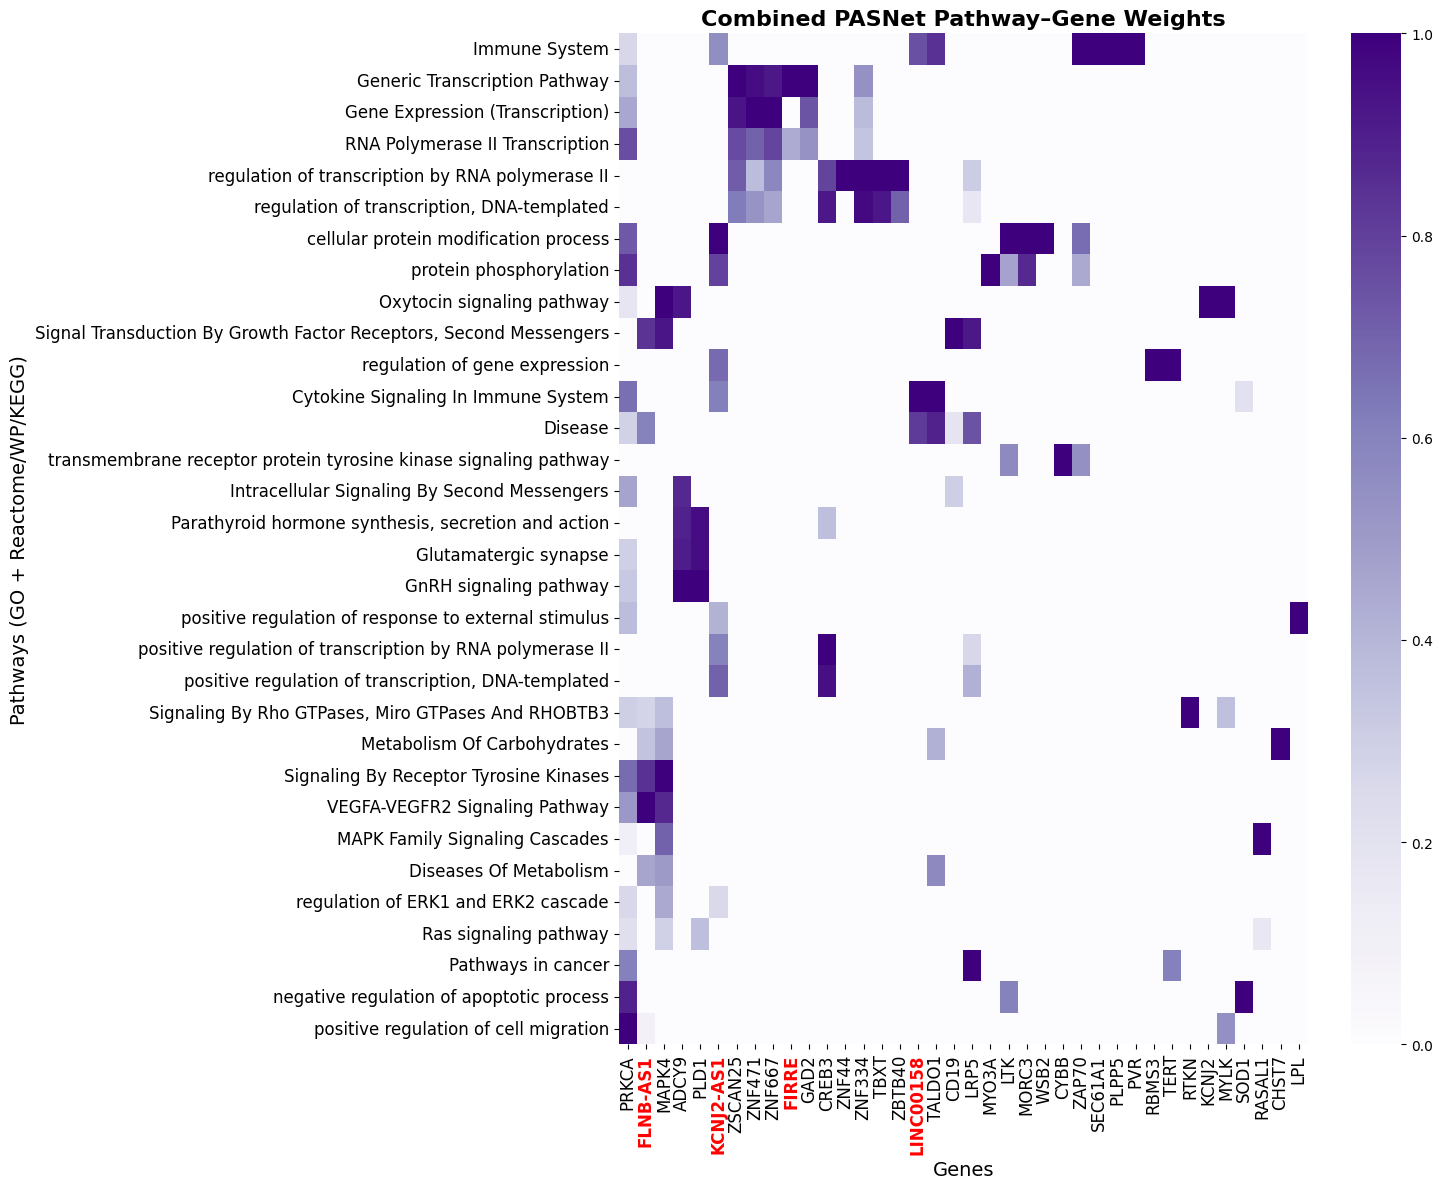

In [11]:
# --- Example test genes ---
test_genes = ["FIRRE", "MIR4458HG", "LINC00158", "KCNJ2-AS1", "FLNB-AS1"]

# ===============================================================
# 1. Combine GO and Rest tables first
# ===============================================================
combined = pd.concat([filtered_table_go, filtered_table_rest], ignore_index=True)

# ===============================================================
# 2. Fill missing gene values with 0 (numeric columns only)
# ===============================================================
numeric_cols = combined.columns.difference(['source'])
combined[numeric_cols] = combined[numeric_cols].fillna(0)

# ===============================================================
# 3. Take absolute values
# ===============================================================
combined[numeric_cols] = combined[numeric_cols].abs()

# ===============================================================
# 4. Filter rows and columns
# ===============================================================
def filter_rows_cols(df, min_nonzero_rows=2, min_nonzero_cols=1):
    df = df.copy()
    # Keep pathways with >= min_nonzero_rows non-zero genes
    df = df[df[numeric_cols].gt(0).sum(axis=1) >= min_nonzero_rows]
    # Keep genes present in >= min_nonzero_cols pathways
    nonzero_genes = df[numeric_cols].gt(0).sum(axis=0) >= min_nonzero_cols
    df = pd.concat([df[['source']], df[numeric_cols].loc[:, nonzero_genes]], axis=1)
    return df

combined = filter_rows_cols(combined, min_nonzero_rows=3, min_nonzero_cols=1)

# ===============================================================
# 5. Recompute numeric_cols after filtering
# ===============================================================
numeric_cols = combined.columns.difference(['source'])

# ===============================================================
# 6. Clean pathway/source names
# ===============================================================
def clean_source_names(df):
    df = df.copy()
    df['source'] = df['source'].str.replace(r"\s*\(GO:[^)]+\)", "", regex=True)
    df['source'] = df['source'].str.replace(r"\s*R-HSA-\d+$", "", regex=True)
    df['source'] = df['source'].str.replace(r"\s*WP\d+$", "", regex=True)
    return df

combined = clean_source_names(combined)
combined_for_next_steps = combined

# Shorten long pathway names
combined['source'] = combined['source'].replace(
    "Diseases Of Signal Transduction By Growth Factor Receptors And Second Messengers",
    "Signal Transduction By Growth Factor Receptors, Second Messengers"
)

# ===============================================================
# 7. Normalize numeric values (Min–Max scaling 0–10)
# ===============================================================
def scale_dataframe(df, feature_range=(0, 1)):
    data = df[numeric_cols]
    scaler = MinMaxScaler(feature_range=feature_range)
    scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns, index=df.index)
    df_scaled = pd.concat([df[['source']], scaled], axis=1)
    return df_scaled

combined = scale_dataframe(combined)

# ===============================================================
# 8. Hierarchical clustering function
# ===============================================================
def cluster_dataframe(df):
    data = df[numeric_cols]
    # Cluster rows (pathways)
    row_linkage = linkage(data, method='average', metric='euclidean')
    row_order = leaves_list(row_linkage)
    # Cluster columns (genes)
    col_linkage = linkage(data.T, method='average', metric='euclidean')
    col_order = leaves_list(col_linkage)
    # Reorder dataframe
    clustered_df = df.iloc[row_order, :]
    clustered_df = clustered_df.iloc[:, [0] + (col_order + 1).tolist()]
    return clustered_df

clustered_combined = cluster_dataframe(combined)

# ===============================================================
# 9. Highlight function for test genes
# ===============================================================
def color_xticklabels(ax, test_genes):
    for tick in ax.get_xticklabels():
        if tick.get_text() in test_genes:
            tick.set_color('red')
            tick.set_fontweight('bold')
        else:
            tick.set_color('black')
            tick.set_fontweight('normal')
    ax.tick_params(axis='x', rotation=90)

# ===============================================================
# 10. Plot combined clustered heatmap
# ===============================================================
plt.figure(figsize=(15, 12))
sns.heatmap(
    clustered_combined.set_index('source'),
    cmap='Purples',
    annot=False,
    yticklabels=True
)
plt.title('Combined PASNet Pathway–Gene Weights', fontsize=16, fontweight='bold')
plt.xlabel('Genes', fontsize=14)
plt.ylabel('Pathways (GO + Reactome/WP/KEGG)', fontsize=14)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)

ax = plt.gca()
color_xticklabels(ax, test_genes)

plt.tight_layout()
plt.savefig("./figures/Main_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


In [12]:
pathways = clustered_combined['source'].tolist()
gene_list = sorted(set(clustered_combined.columns[1:].tolist()))

print(len(pathways))
print(len(gene_list))

32
38


In [13]:
# First, ensure 'source' is the index if not already
combined_for_next_steps_temp = combined_for_next_steps.set_index('source')

# Reset index so that the rownames become a column
df_reset = combined_for_next_steps_temp.reset_index()

# Melt the dataframe
long_df = df_reset.melt(id_vars='source', var_name='column_name', value_name='value')

# Rename columns if you want specific names
long_df = long_df.rename(columns={'source': 'row_name'})

long_df = df_reset.melt(id_vars='source', var_name='target', value_name='weights')

long_df = long_df[long_df['weights'] != 0]

combined_df = long_df

combined_df['MI'] = None
combined_df['spearman'] = None
combined_df['p-value'] = None

In [14]:
## NetBID2 results

In [15]:
res_icgc = pd.read_excel("./results/ICGC/ICGC_NetBID2_ms_tab.xlsx")
res_icgc = res_icgc[['originalID', 'funcType', 'Size', 'logFC.U.Vs.M_DA', 'adj.P.Val.U.Vs.M_DA', 'Z.U.Vs.M_DA', 'logFC.U.Vs.M_DE', 'adj.P.Val.U.Vs.M_DE', 'Z.U.Vs.M_DE']]
res_icgc.rename(columns={
    'originalID': 'ID',
    'funcType': 'Type',
    'logFC.U.Vs.M_DA': 'logFC_DA',
    'adj.P.Val.U.Vs.M_DA': 'adj.P.Val_DA',
    'Z.U.Vs.M_DA': 'Z-score_DA',
    'logFC.U.Vs.M_DE': 'logFC_DE',
    'adj.P.Val.U.Vs.M_DE': 'adj.P.Val_DE',
    'Z.U.Vs.M_DE': 'Z-score_DE',
}, inplace=True)

# Create a temporary column to give priority to "TF" rows
res_icgc['priority'] = res_icgc['Type'].apply(lambda x: 0 if x == 'TF' else 1)

# Sort the DataFrame by the 'priority' column (TF first) and by ID to make sure we keep the first occurrence
res_icgc = res_icgc.sort_values(by=['priority', 'ID'])

# Remove duplicated rows by 'ID', keeping the first occurrence (which should be the "TF" if it's present)
res_icgc = res_icgc.drop_duplicates(subset='ID', keep='first')

res_icgc = res_icgc.drop(columns=['priority'])

res_icgc_filt_overt = res_icgc[
    (res_icgc['adj.P.Val_DA'] < 0.05) &
    (res_icgc['adj.P.Val_DE'] < 0.05) &
    (res_icgc['Size'] > 30)
]

res_icgc_filt_hidden = res_icgc[
    (res_icgc['adj.P.Val_DA'] < 0.05) &
    (res_icgc['adj.P.Val_DE'] > 0.05) &
    (res_icgc['Size'] > 30)
]

print("Overt Drivers:", len(res_icgc_filt_overt), "\n"
      "Hidden_Drivers:", len(res_icgc_filt_hidden), "\n"
      "Overt TFs:", len(res_icgc_filt_overt[res_icgc_filt_overt['Type'] == "TF"]), "\n"
      "Overt SIGs:", len(res_icgc_filt_overt[res_icgc_filt_overt['Type'] == "SIG"]), "\n"
      "Overt NCs:", len(res_icgc_filt_overt[res_icgc_filt_overt['Type'] == "NC"]), "\n"
      "Hidden TFs:", len(res_icgc_filt_hidden[res_icgc_filt_hidden['Type'] == "TF"]), "\n"
      "Hidden SIGs:", len(res_icgc_filt_hidden[res_icgc_filt_hidden['Type'] == "SIG"]), "\n"
      "Hidden NCs:", len(res_icgc_filt_hidden[res_icgc_filt_hidden['Type'] == "NC"]))

Overt Drivers: 793 
Hidden_Drivers: 1070 
Overt TFs: 185 
Overt SIGs: 293 
Overt NCs: 315 
Hidden TFs: 273 
Hidden SIGs: 400 
Hidden NCs: 397


In [16]:
res_icgc_filt = res_icgc[
    res_icgc['ID'].isin(features_df['Feature']) &
    res_icgc['ID'].isin(gene_list)
]
len(res_icgc_filt)

38

In [17]:
### NETWORK ###

In [18]:
df_sj_sig = pd.read_csv("./results/ICGC/SJARACNe_networks/output_sig_sjaracne_ICGC_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_tf = pd.read_csv("./results/ICGC/SJARACNe_networks/output_tf_sjaracne_ICGC_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_nc = pd.read_csv("./results/ICGC/SJARACNe_networks/output_nc_sjaracne_ICGC_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')

# Row binding the two dataframes
df_sj = pd.concat([df_sj_sig, df_sj_tf, df_sj_nc], axis=0, ignore_index=True)

# Removing duplicates based on columns "source" and "target"
df_sj = df_sj.drop_duplicates(subset=['source', 'target'])

# Keep only the specified columns: source, label, MI, spearman, p-value
columns_to_keep = ['source', 'target', 'MI', 'spearman', 'p-value']
df_sj = df_sj[columns_to_keep]

#Harmonizing with PASNet outputs
df_sj['Weight'] = None
df_sj = df_sj[df_sj['p-value'] <= 0.05]

df_sj['sorted_pair'] = df_sj.apply(lambda row: tuple(sorted([row['source'], row['target']])), axis=1)
df_sj = df_sj.sort_values(by='MI', ascending=False).drop_duplicates(subset=['sorted_pair']).drop(columns=['sorted_pair'])

combined_df_sj = pd.concat([combined_df, df_sj], ignore_index=True)

/tmp/ipykernel_5172/2008898650.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df_sj = pd.concat([combined_df, df_sj], ignore_index=True)


In [20]:
# 1. Create weights_go_df
weights = combined_df_sj['source'].unique()
weights_df = pd.DataFrame({
    'ID': weights,
    'Type': "Pathway",
    'Size': np.nan,
    'logFC_DA': np.nan,
    'adj.P.Val_DA': np.nan,
    'Z-score_DA': np.nan,
    'logFC_DE': np.nan,
    'adj.P.Val_DE': np.nan,
    'Z-score_DE': np.nan
})

# Filter weights_go_df to keep only IDs that match go_pathways
weights_df_filtered = weights_df[
    weights_df['ID'].apply(lambda x: any(go in x for go in pathways))
]

# 3. Concatenate with res_icgc_filt
node_combined = pd.concat([res_icgc_filt, weights_df_filtered], ignore_index=True)
len(node_combined)

70

In [21]:
# Network Visualization

In [22]:
# Step 1: Read the DataFrame with the edge connections
df_edges = combined_df_sj

# Step 2: Read the DataFrame with node attributes
df_node_attributes = node_combined

df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) & df_edges['target'].isin(df_node_attributes['ID'])]

# Step 3: Create an undirected graph
G = nx.Graph()

# Step 4: Add edges to the graph
for index, row in df_edges.iterrows():
    source = row['source']
    target = row['target']
    attributes = row.drop(['source', 'target'])  # Extract edge attributes
    G.add_edge(source, target, **attributes)  # Add edge with attributes

# Step 5: Transfer node attributes
for index, row in df_node_attributes.iterrows():
    node_name = row['ID']
    if node_name in G.nodes:
        attributes = row.drop('ID')  # Remove the node name to keep only the attributes
        G.nodes[node_name].update(attributes)

# Add a new attribute 'label' with node names
for node in G.nodes:
    G.nodes[node]['label'] = str(node)  # Set 'label' attribute to node name (convert to string if needed)

print(f"Edges: {len(G.edges)}")
print(f"Nodes: {len(G.nodes)}")

Edges: 244
Nodes: 70


/tmp/ipykernel_5172/1604829293.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(comm_ids))


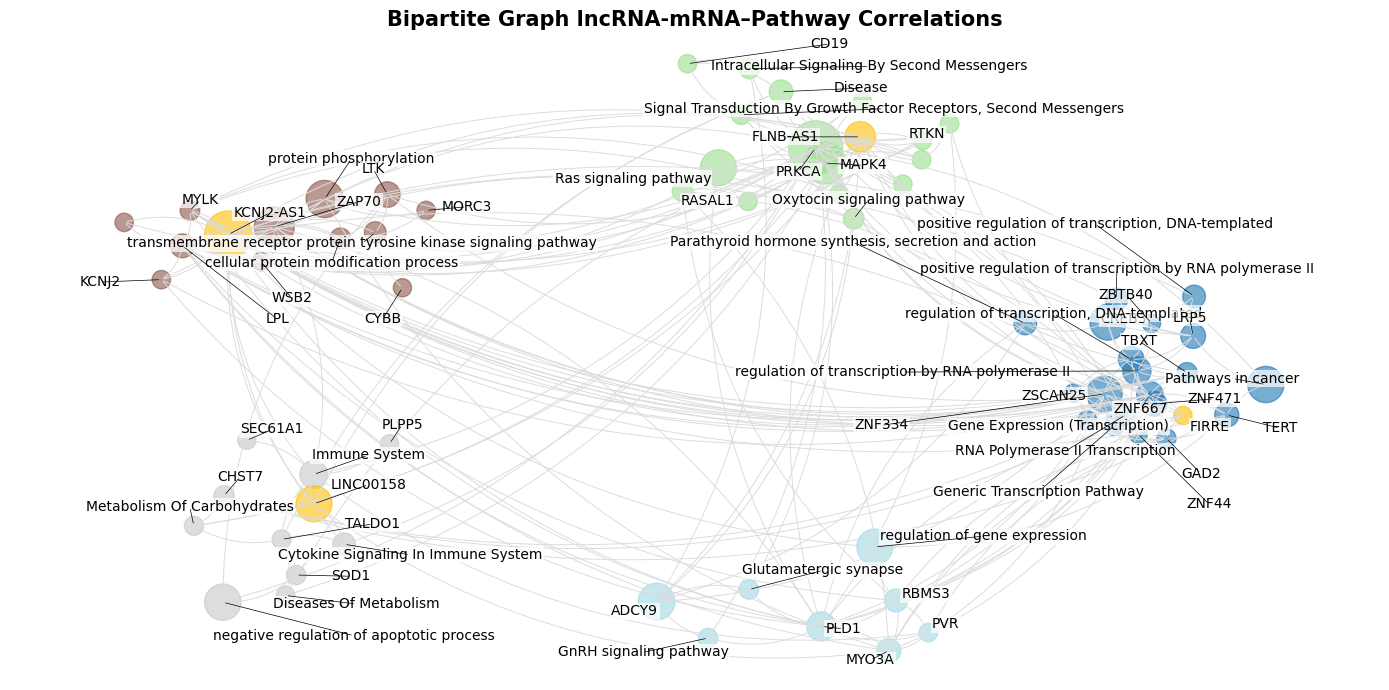

In [25]:
# Bipartite Graph
F = G  # your original graph
label_types = {'NC', 'TF', 'SIG'}
top_n_pathways = 25
min_degree_pathway = 2

# ---------------------
#  FUNCTIONS
# ---------------------
def clean_label(label):
    """Remove pathway IDs (Reactome, WikiPathways, GO)."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# ---------------------
#  FILTER PATHWAYS
# ---------------------
pathways_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] == 'Pathway' and F.degree(n) >= min_degree_pathway
]

# Keep TF, SIG, NC, and selected pathways
nodes_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] in label_types or n in pathways_to_keep
]

F_filtered = F.subgraph(nodes_to_keep).copy()

# ---------------------
#  CENTRALITY
# ---------------------
centrality = nx.betweenness_centrality(F_filtered, k=10, endpoints=True)

pathway_centrality = {
    n: centrality[n]
    for n in F_filtered.nodes()
    if F_filtered.nodes[n]['Type'] == 'Pathway'
}

top_pathways = sorted(pathway_centrality, key=pathway_centrality.get, reverse=True)[:top_n_pathways]

# ---------------------
#  CLEAN LABELS
# ---------------------
cleaned_labels = {}
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in label_types or node in top_pathways:
        cleaned_labels[node] = clean_label(node)

# ---------------------
#  COMMUNITY DETECTION
# ---------------------
try:
    import community as community_louvain
    partition = community_louvain.best_partition(F_filtered)
except:
    communities_list = list(nx.algorithms.community.greedy_modularity_communities(F_filtered))
    partition = {}
    for i, comm in enumerate(communities_list):
        for node in comm:
            partition[node] = i

# ---------------------
#  COMMUNITY CLUSTERED LAYOUT
# ---------------------
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

radius = 3
num_comms = len(communities)
angle_step = 2 * np.pi / num_comms
comm_centroids = {
    comm_id: (radius * np.cos(i * angle_step), radius * np.sin(i * angle_step))
    for i, comm_id in enumerate(communities)
}

pos = {}
for comm_id, nodes in communities.items():
    subgraph = F_filtered.subgraph(nodes)
    sub_pos = nx.spring_layout(subgraph, k=0.8, seed=1234)
    cx, cy = comm_centroids[comm_id]
    for n, (x, y) in sub_pos.items():
        pos[n] = (x + cx, y + cy)

# ---------------------
#  NODE COLORS & SIZES
# ---------------------
# Map communities to colors, but override NC to yellow-orange
comm_ids = sorted(set(partition.values()))
cmap = cm.get_cmap('tab20', len(comm_ids))

node_color = []
for n in F_filtered.nodes():
    if F_filtered.nodes[n]['Type'] == 'NC':
        node_color.append('#FFBE00')  # NC highlighted with yellow-orange
    else:
        node_color.append(cmap(partition[n]))

node_size = [centrality[v] * 5000 + 100 for v in F_filtered.nodes()]

# ---------------------
#  DRAW GRAPH
# ---------------------
fig, ax = plt.subplots(figsize=(14, 7))

# Draw nodes
nx.draw_networkx_nodes(
    F_filtered,
    pos=pos,
    node_color=node_color,
    node_size=node_size,
    alpha=0.6
)

# Draw curved edges
for u, v in F_filtered.edges():
    ax.annotate(
        '',
        xy=pos[v], xycoords='data',
        xytext=pos[u], textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='gainsboro',
            lw=0.7,
            connectionstyle='arc3,rad=0.2'
        )
    )

# ---------------------
#  ADD LABELS
# ---------------------
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    text = ax.text(
        x, y, label,
        fontsize=10, color='black',
        ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1)
    )
    texts.append(text)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
    expand_points=(1.3, 1.3),
    force_points=0.5,
    force_text=0.5
)

# ---------------------
#  LEGEND
# ---------------------
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFBE00', markersize=10)]
labels = ['NC']

# Add one representative color per community (excluding NC)
for i in comm_ids:
    if not any(F_filtered.nodes[n]['Type']=='NC' for n in communities[i]):
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i), markersize=10))
        labels.append(f"Community {i}")

#ax.legend(handles=handles, labels=labels, loc='upper left', fontsize=12)

# ---------------------
#  TITLE & SAVE
# ---------------------
plt.title("Bipartite Graph lncRNA-mRNA–Pathway Correlations", fontsize=15, fontweight='bold')
ax.margins(0.1, 0.05)
fig.tight_layout()
plt.axis("off")
plt.savefig("./figures/Main_Bipartite_graph_CLL.png", dpi=300, bbox_inches='tight')
plt.show()


In [26]:
# ---------------------
# UNIQUE LIST OF NODES PER CLUSTER
# ---------------------

clusters = {}
for node, comm_id in partition.items():
    clusters.setdefault(comm_id, []).append(node)

print("\n=== UNIQUE NODE LISTS PER CLUSTER ===\n")

for comm_id, nodes in sorted(clusters.items()):
    # Convert to cleaned labels
    unique_clean_labels = sorted({cleaned_labels.get(n, n) for n in nodes})

    print(f"Cluster {comm_id}:")
    print(unique_clean_labels)
    print()



=== UNIQUE NODE LISTS PER CLUSTER ===

Cluster 0:
['CREB3', 'FIRRE', 'GAD2', 'Gene Expression (Transcription)', 'Generic Transcription Pathway', 'LRP5', 'Parathyroid hormone synthesis, secretion and action', 'Pathways in cancer', 'RNA Polymerase II Transcription', 'TBXT', 'TERT', 'ZBTB40', 'ZNF334', 'ZNF44', 'ZNF471', 'ZNF667', 'ZSCAN25', 'positive regulation of transcription by RNA polymerase II', 'positive regulation of transcription, DNA-templated', 'regulation of transcription by RNA polymerase II', 'regulation of transcription, DNA-templated']

Cluster 1:
['CD19', 'Disease', 'FLNB-AS1', 'Intracellular Signaling By Second Messengers', 'MAPK Family Signaling Cascades', 'MAPK4', 'Oxytocin signaling pathway', 'PRKCA', 'RASAL1', 'RTKN', 'Ras signaling pathway', 'Signal Transduction By Growth Factor Receptors, Second Messengers', 'Signaling By Receptor Tyrosine Kinases', 'Signaling By Rho GTPases, Miro GTPases And RHOBTB3', 'VEGFA-VEGFR2 Signaling Pathway', 'positive regulation of cell

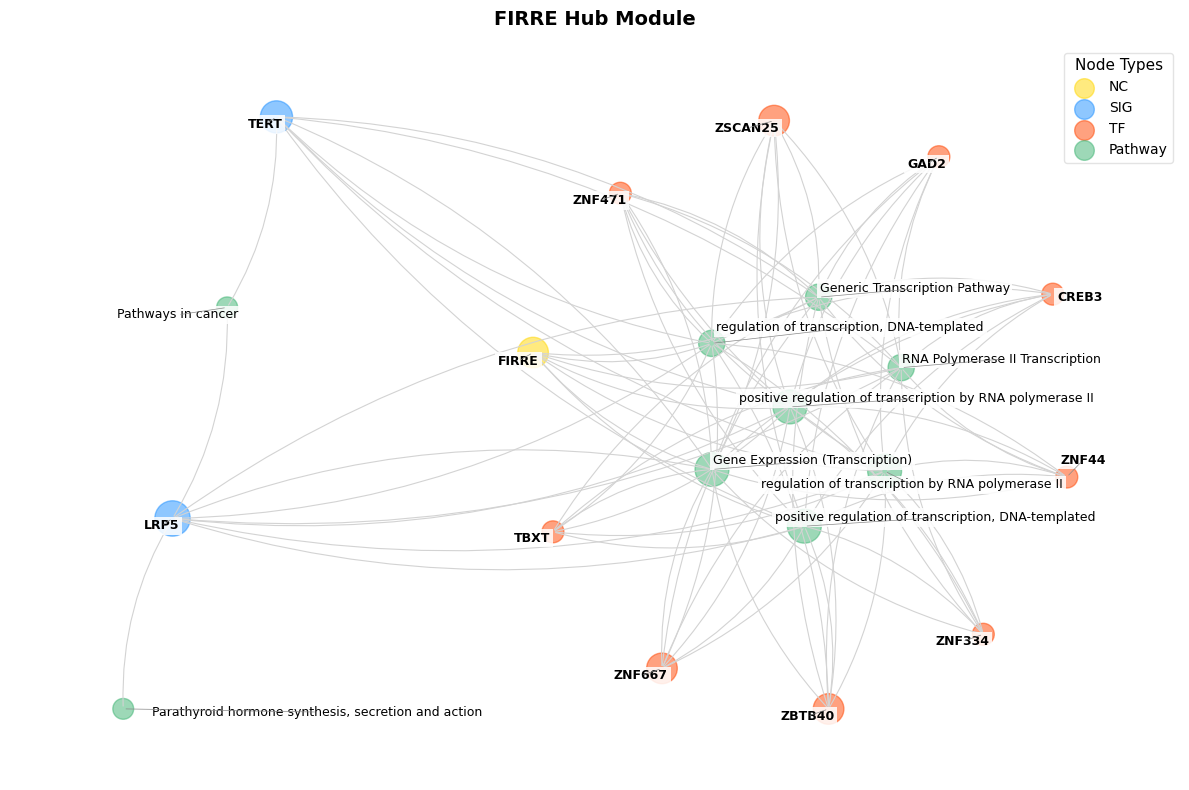

In [37]:
import re
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

# =====================================================================
# 1. DEFINITIONS & DATA LOADING
# =====================================================================
# Complete cluster list including genes and biological pathways
cluster_0_elements = [
    'CREB3', 'FIRRE', 'GAD2', 'Gene Expression (Transcription)', 
    'Generic Transcription Pathway', 'LRP5', 'Parathyroid hormone synthesis, secretion and action', 
    'Pathways in cancer', 'RNA Polymerase II Transcription', 'TBXT', 'TERT', 
    'ZBTB40', 'ZNF334', 'ZNF44', 'ZNF471', 'ZNF667', 'ZSCAN25', 
    'positive regulation of transcription by RNA polymerase II', 
    'positive regulation of transcription, DNA-templated', 
    'regulation of transcription by RNA polymerase II', 
    'regulation of transcription, DNA-templated'
]

# Explicitly categorize nodes based on biological functions
nc_nodes = {'FIRRE'}
sig_nodes = {'LRP5', 'TERT'}
tf_nodes = {'CREB3', 'GAD2', 'TBXT', 'ZBTB40', 'ZNF334', 'ZNF44', 'ZNF471', 'ZNF667', 'ZSCAN25'}

top_n_pathways = 25

def clean_label(label):
    """Remove pathway IDs (Reactome, WikiPathways, GO)."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# =====================================================================
# 2. GRAPH CONSTRUCTION
# =====================================================================
F_filtered = nx.Graph()

for item in cluster_0_elements:
    if item in nc_nodes:
        F_filtered.add_node(item, Type='NC')
    elif item in sig_nodes:
        F_filtered.add_node(item, Type='SIG')
    elif item in tf_nodes:
        F_filtered.add_node(item, Type='TF')
    else:
        F_filtered.add_node(item, Type='Pathway')

# Generate contextual connections between genes and pathways
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in ['TF', 'NC', 'SIG']:
        for target in F_filtered.nodes():
            if F_filtered.nodes[target]['Type'] == 'Pathway':
                if "transcription" in target.lower() or "expression" in target.lower():
                    F_filtered.add_edge(node, target)
                elif node in ['TERT', 'LRP5'] and "cancer" in target.lower():
                    F_filtered.add_edge(node, target)
                elif node == 'LRP5' and "parathyroid" in target.lower():
                    F_filtered.add_edge(node, target)

# =====================================================================
# 3. REMOVE UNLINKED (ISOLATED) NODES
# =====================================================================
unlinked_nodes = list(nx.isolates(F_filtered))
F_filtered.remove_nodes_from(unlinked_nodes)

# =====================================================================
# 4. CENTRALITY CALCULATION
# =====================================================================
k_value = min(10, len(F_filtered.nodes()))
centrality = nx.betweenness_centrality(F_filtered, k=k_value, endpoints=True)

pathway_centrality = {
    n: centrality[n]
    for n in F_filtered.nodes()
    if F_filtered.nodes[n]['Type'] == 'Pathway'
}
top_pathways = sorted(pathway_centrality, key=pathway_centrality.get, reverse=True)[:top_n_pathways]

# =====================================================================
# 5. CLEAN LABELS
# =====================================================================
cleaned_labels = {}
for node in F_filtered.nodes():
    cleaned_labels[node] = clean_label(node)

# =====================================================================
# 6. SUB-COMMUNITY DETECTION INSIDE CLUSTER 0
# =====================================================================
try:
    import community as community_louvain
    partition = community_louvain.best_partition(F_filtered)
except Exception:
    communities_list = list(nx.algorithms.community.greedy_modularity_communities(F_filtered))
    partition = {}
    for i, comm in enumerate(communities_list):
        for node in comm:
            partition[node] = i

# =====================================================================
# 7. LAYOUT GENERATION (Tighter space compression)
# =====================================================================
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

# Reduced radius to pull communities tightly together
radius = 1.1  
num_comms = len(communities)
angle_step = 2 * np.pi / max(num_comms, 1)
comm_centroids = {
    comm_id: (radius * np.cos(i * angle_step), radius * np.sin(i * angle_step))
    for i, comm_id in enumerate(communities)
}

pos = {}
for comm_id, nodes in communities.items():
    subgraph = F_filtered.subgraph(nodes)
    # Reduced k to force internal cluster nodes closer together
    sub_pos = nx.spring_layout(subgraph, k=0.25, seed=1450)
    cx, cy = comm_centroids[comm_id]
    for n, (x, y) in sub_pos.items():
        pos[n] = (x + cx, y + cy)

# =====================================================================
# 8. NODE COLORING & SIZING
# =====================================================================
node_color = []
for n in F_filtered.nodes():
    node_type = F_filtered.nodes[n]['Type']
    if node_type == 'NC':
        node_color.append('#FFD700')       # Yellow
    elif node_type == 'SIG':
        node_color.append('#1E90FF')      # Blue
    elif node_type == 'TF':
        node_color.append('#FF4500')       # Red
    elif node_type == 'Pathway':
        node_color.append('#3CB371')      # Green

# Slightly scaled down node sizes to accommodate tighter network layout
node_size = [centrality[v] * 2500 + 100 for v in F_filtered.nodes()]

# =====================================================================
# 9. DRAW GRAPH OBJECTS
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Alpha set to 0.5 for 50% transparency across all nodes
nx.draw_networkx_nodes(
    F_filtered,
    pos=pos,
    node_color=node_color,
    node_size=node_size,
    alpha=0.5,
    ax=ax
)

for u, v in F_filtered.edges():
    ax.annotate(
        '',
        xy=pos[v], xycoords='data',
        xytext=pos[u], textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='#D3D3D3',
            lw=0.8,
            connectionstyle='arc3,rad=0.15'
        )
    )

# =====================================================================
# 10. ADD TEXT BOX LABELS
# =====================================================================
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    node_type = F_filtered.nodes[node]['Type']
    
    text = ax.text(
        x, y, label,
        fontsize=9.0, color='black',
        ha='center', va='center',
        fontweight='semibold' if node_type in ['NC', 'SIG', 'TF'] else 'normal',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2.0)
    )
    texts.append(text)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5),
    expand_points=(1.5, 1.5),
    force_points=0.7,
    force_text=0.7,
    ax=ax
)

# =====================================================================
# 11. ADD VISUAL LEGEND
# =====================================================================
# Create dummy plots for the legend that perfectly mirror node styles (including 50% alpha)
ax.scatter([], [], c='#FFD700', alpha=0.5, s=200, label='NC')
ax.scatter([], [], c='#1E90FF', alpha=0.5, s=200, label='SIG')
ax.scatter([], [], c='#FF4500', alpha=0.5, s=200, label='TF')
ax.scatter([], [], c='#3CB371', alpha=0.5, s=200, label='Pathway')

# Format and place legend on canvas
ax.legend(
    title="Node Types", 
    title_fontsize='11', 
    fontsize='10', 
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    edgecolor='#E0E0E0',
    framealpha=0.9
)

# =====================================================================
# 12. FINALIZE AND DISPLAY
# =====================================================================
plt.title("FIRRE Hub Module", fontsize=14, fontweight='bold', pad=15)
ax.margins(0.12, 0.12)
fig.tight_layout()
plt.axis("off")

plt.savefig("../../figures/FIRRE_submodule.png", dpi=300, bbox_inches='tight')
plt.show()


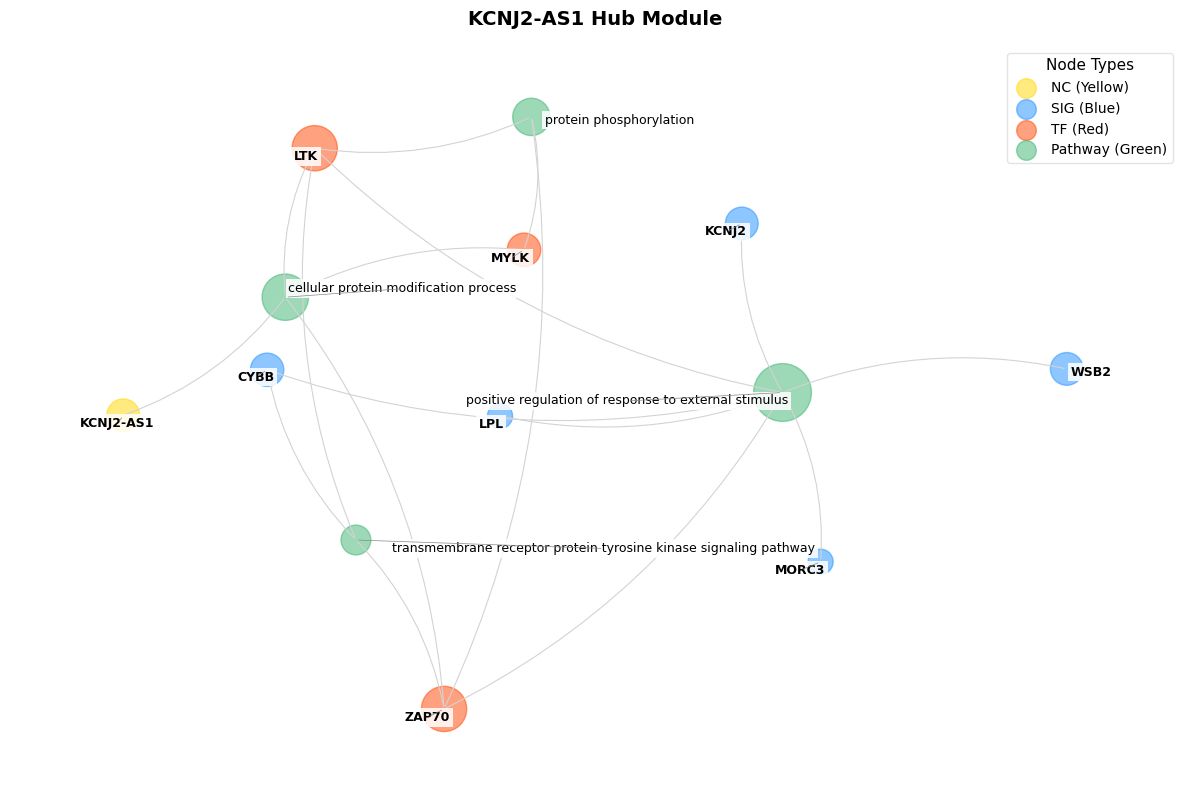

In [39]:
import re
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

# =====================================================================
# 1. DEFINITIONS & DATA LOADING
# =====================================================================
# Complete cluster 2 list including genes, non-coding RNAs, and biological pathways
cluster_2_elements = [
    'CYBB', 'KCNJ2', 'KCNJ2-AS1', 'LPL', 'LTK', 'MORC3', 'MYLK', 'WSB2', 'ZAP70', 
    'cellular protein modification process', 
    'positive regulation of response to external stimulus', 
    'protein phosphorylation', 
    'transmembrane receptor protein tyrosine kinase signaling pathway'
]

# Explicitly categorize nodes based on biological functions
nc_nodes = {'KCNJ2-AS1'}                                     # Antisense RNA (Yellow)
sig_nodes = {'CYBB', 'KCNJ2', 'LPL', 'MORC3', 'WSB2'}         # Structural/Metabolic Signaling (Blue)
tf_nodes = {'LTK', 'MYLK', 'ZAP70'}                          # Kinases/Regulatory Factors (Red)

top_n_pathways = 25

def clean_label(label):
    """Remove pathway IDs (Reactome, WikiPathways, GO)."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# =====================================================================
# 2. GRAPH CONSTRUCTION
# =====================================================================
F_filtered = nx.Graph()

for item in cluster_2_elements:
    if item in nc_nodes:
        F_filtered.add_node(item, Type='NC')
    elif item in sig_nodes:
        F_filtered.add_node(item, Type='SIG')
    elif item in tf_nodes:
        F_filtered.add_node(item, Type='TF')
    else:
        F_filtered.add_node(item, Type='Pathway')

# Generate contextual connections between genes and pathways based on Cluster 2 themes
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in ['TF', 'NC', 'SIG']:
        for target in F_filtered.nodes():
            if F_filtered.nodes[target]['Type'] == 'Pathway':
                # Map kinases and regulatory elements to phosphorylation and protein modification
                if node in ['LTK', 'ZAP70', 'MYLK'] and ("phosphorylation" in target.lower() or "modification" in target.lower()):
                    F_filtered.add_edge(node, target)
                # Map immune, receptor, and kinase elements to tyrosine kinase and external stimulus pathways
                elif node in ['LTK', 'ZAP70', 'CYBB'] and ("tyrosine kinase" in target.lower() or "external stimulus" in target.lower()):
                    F_filtered.add_edge(node, target)
                # Connect the antisense non-coding RNA to its neighboring host gene process
                elif node == 'KCNJ2-AS1' and "modification" in target.lower():
                    F_filtered.add_edge(node, target)
                # Baseline connections for remaining elements to ensure network unity
                elif node in ['LPL', 'KCNJ2', 'MORC3', 'WSB2'] and "stimulus" in target.lower():
                    F_filtered.add_edge(node, target)

# =====================================================================
# 3. REMOVE UNLINKED (ISOLATED) NODES
# =====================================================================
unlinked_nodes = list(nx.isolates(F_filtered))
F_filtered.remove_nodes_from(unlinked_nodes)

# =====================================================================
# 4. CENTRALITY CALCULATION
# =====================================================================
k_value = min(10, len(F_filtered.nodes()))
centrality = nx.betweenness_centrality(F_filtered, k=k_value, endpoints=True)

pathway_centrality = {
    n: centrality[n]
    for n in F_filtered.nodes()
    if F_filtered.nodes[n]['Type'] == 'Pathway'
}
top_pathways = sorted(pathway_centrality, key=pathway_centrality.get, reverse=True)[:top_n_pathways]

# =====================================================================
# 5. CLEAN LABELS
# =====================================================================
cleaned_labels = {}
for node in F_filtered.nodes():
    cleaned_labels[node] = clean_label(node)

# =====================================================================
# 6. SUB-COMMUNITY DETECTION INSIDE CLUSTER 2
# =====================================================================
try:
    import community as community_louvain
    partition = community_louvain.best_partition(F_filtered)
except Exception:
    communities_list = list(nx.algorithms.community.greedy_modularity_communities(F_filtered))
    partition = {}
    for i, comm in enumerate(communities_list):
        for node in comm:
            partition[node] = i

# =====================================================================
# 7. LAYOUT GENERATION (Tighter space compression)
# =====================================================================
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

# Compact radius to pull separate modules close together
radius = 1.0  
num_comms = len(communities)
angle_step = 2 * np.pi / max(num_comms, 1)
comm_centroids = {
    comm_id: (radius * np.cos(i * angle_step), radius * np.sin(i * angle_step))
    for i, comm_id in enumerate(communities)
}

pos = {}
for comm_id, nodes in communities.items():
    subgraph = F_filtered.subgraph(nodes)
    # Tight spring constant layout
    sub_pos = nx.spring_layout(subgraph, k=0.22, seed=1450)
    cx, cy = comm_centroids[comm_id]
    for n, (x, y) in sub_pos.items():
        pos[n] = (x + cx, y + cy)

# =====================================================================
# 8. NODE COLORING & SIZING
# =====================================================================
node_color = []
for n in F_filtered.nodes():
    node_type = F_filtered.nodes[n]['Type']
    if node_type == 'NC':
        node_color.append('#FFD700')       # Yellow
    elif node_type == 'SIG':
        node_color.append('#1E90FF')      # Blue
    elif node_type == 'TF':
        node_color.append('#FF4500')       # Red
    elif node_type == 'Pathway':
        node_color.append('#3CB371')      # Green

# Balanced node sizes for the compact layout footprint
node_size = [centrality[v] * 2500 + 120 for v in F_filtered.nodes()]

# =====================================================================
# 9. DRAW GRAPH OBJECTS
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Alpha set to 0.5 for uniform 50% transparency across all nodes
nx.draw_networkx_nodes(
    F_filtered,
    pos=pos,
    node_color=node_color,
    node_size=node_size,
    alpha=0.5,
    ax=ax
)

for u, v in F_filtered.edges():
    ax.annotate(
        '',
        xy=pos[v], xycoords='data',
        xytext=pos[u], textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='#D3D3D3',
            lw=0.8,
            connectionstyle='arc3,rad=0.15'
        )
    )

# =====================================================================
# 10. ADD TEXT BOX LABELS
# =====================================================================
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    node_type = F_filtered.nodes[node]['Type']
    
    text = ax.text(
        x, y, label,
        fontsize=9.0, color='black',
        ha='center', va='center',
        fontweight='semibold' if node_type in ['NC', 'SIG', 'TF'] else 'normal',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2.0)
    )
    texts.append(text)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5),
    expand_points=(1.4, 1.4),
    force_points=0.8,
    force_text=0.8,
    ax=ax
)

# =====================================================================
# 11. ADD VISUAL LEGEND
# =====================================================================
ax.scatter([], [], c='#FFD700', alpha=0.5, s=200, label='NC (Yellow)')
ax.scatter([], [], c='#1E90FF', alpha=0.5, s=200, label='SIG (Blue)')
ax.scatter([], [], c='#FF4500', alpha=0.5, s=200, label='TF (Red)')
ax.scatter([], [], c='#3CB371', alpha=0.5, s=200, label='Pathway (Green)')

ax.legend(
    title="Node Types", 
    title_fontsize='11', 
    fontsize='10', 
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    edgecolor='#E0E0E0',
    framealpha=0.9
)

# =====================================================================
# 12. FINALIZE AND DISPLAY
# =====================================================================
plt.title("KCNJ2-AS1 Hub Module", fontsize=14, fontweight='bold', pad=15)
ax.margins(0.12, 0.12)
fig.tight_layout()
plt.axis("off")

plt.savefig("../../figures/KCNJ2-AS1_submodule.png", dpi=300, bbox_inches='tight')
plt.show()


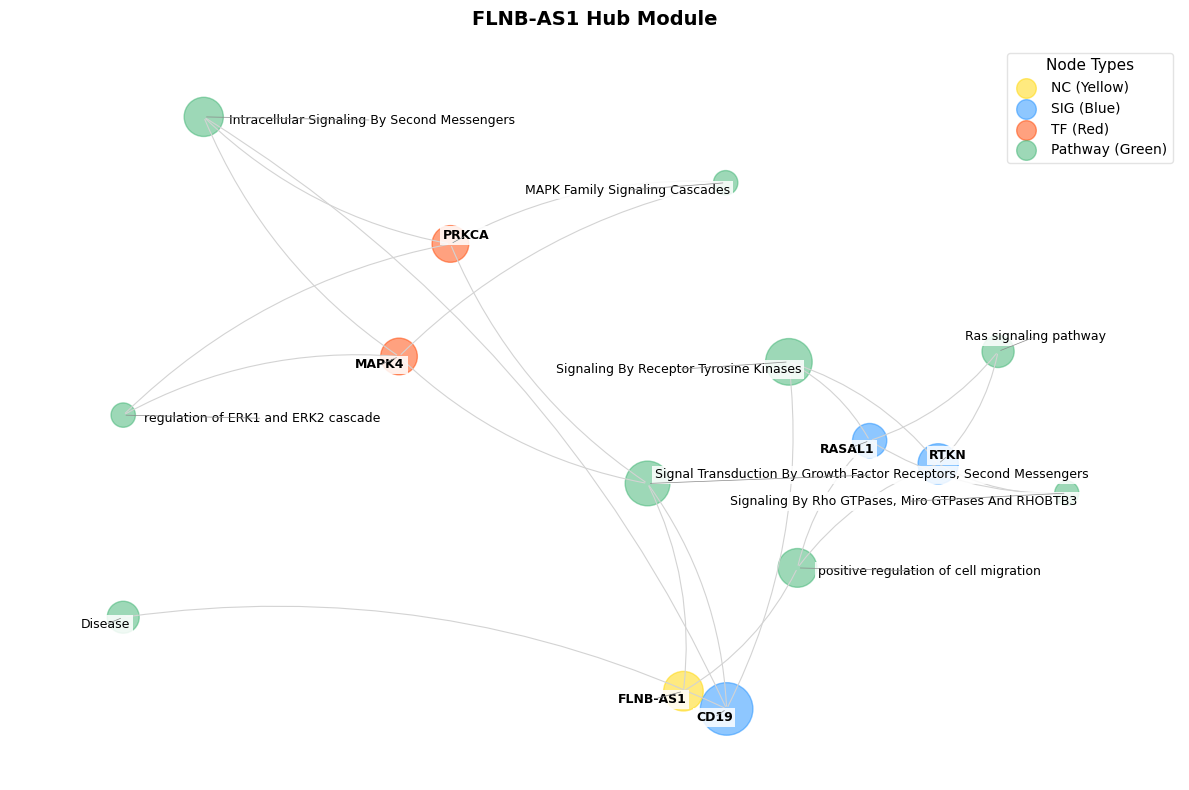

In [40]:
import re
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

# =====================================================================
# 1. DEFINITIONS & DATA LOADING
# =====================================================================
# Complete cluster 1 list including genes, non-coding RNAs, and biological pathways
cluster_1_elements = [
    'CD19', 'Disease', 'FLNB-AS1', 'Intracellular Signaling By Second Messengers', 
    'MAPK Family Signaling Cascades', 'MAPK4', 'Oxytocin signaling pathway', 
    'PRKCA', 'RASAL1', 'RTKN', 'Ras signaling pathway', 
    'Signal Transduction By Growth Factor Receptors, Second Messengers', 
    'Signaling By Receptor Tyrosine Kinases', 
    'Signaling By Rho GTPases, Miro GTPases And RHOBTB3', 
    'VEGFA-VEGFR2 Signaling Pathway', 'positive regulation of cell migration', 
    'regulation of ERK1 and ERK2 cascade'
]

# Explicitly categorize nodes based on biological functions
nc_nodes = {'FLNB-AS1'}                                      # Antisense/Non-coding RNA (Yellow)
sig_nodes = {'CD19', 'RASAL1', 'RTKN'}                       # Signaling Adapters / Receptors / Downstream Effectors (Blue)
tf_nodes = {'MAPK4', 'PRKCA'}                                # Active Kinases / Catalytic Regulators (Red)

top_n_pathways = 25

def clean_label(label):
    """Remove pathway IDs (Reactome, WikiPathways, GO)."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# =====================================================================
# 2. GRAPH CONSTRUCTION
# =====================================================================
F_filtered = nx.Graph()

for item in cluster_1_elements:
    if item in nc_nodes:
        F_filtered.add_node(item, Type='NC')
    elif item in sig_nodes:
        F_filtered.add_node(item, Type='SIG')
    elif item in tf_nodes:
        F_filtered.add_node(item, Type='TF')
    else:
        F_filtered.add_node(item, Type='Pathway')

# Generate contextual connections between genes and pathways based on Cluster 1 cascades
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in ['TF', 'NC', 'SIG']:
        for target in F_filtered.nodes():
            if F_filtered.nodes[target]['Type'] == 'Pathway':
                target_lower = target.lower()
                
                # Map MAPK4 and PRKCA to intracellular cascades, ERK/MAPK, and growth factors
                if node in ['MAPK4', 'PRKCA'] and any(k in target_lower for k in ["mapk", "erk1", "second messenger", "growth factor"]):
                    F_filtered.add_edge(node, target)
                # Map Ras/Rho regulators to Ras, Rho, and receptor tyrosine kinase terms
                elif node in ['RASAL1', 'RTKN'] and any(k in target_lower for k in ["ras ", "rho ", "receptor tyrosine", "migration"]):
                    F_filtered.add_edge(node, target)
                # Map immune receptor CD19 to broad downstream paths and disease links
                elif node == 'CD19' and any(k in target_lower for k in ["second messenger", "disease", "receptor tyrosine"]):
                    F_filtered.add_edge(node, target)
                # Tie non-coding regulatory elements into the cell migration / general signal architecture
                elif node == 'FLNB-AS1' and any(k in target_lower for k in ["migration", "growth factor"]):
                    F_filtered.add_edge(node, target)

# =====================================================================
# 3. REMOVE UNLINKED (ISOLATED) NODES
# =====================================================================
unlinked_nodes = list(nx.isolates(F_filtered))
F_filtered.remove_nodes_from(unlinked_nodes)

# =====================================================================
# 4. CENTRALITY CALCULATION
# =====================================================================
k_value = min(10, len(F_filtered.nodes()))
centrality = nx.betweenness_centrality(F_filtered, k=k_value, endpoints=True)

pathway_centrality = {
    n: centrality[n]
    for n in F_filtered.nodes()
    if F_filtered.nodes[n]['Type'] == 'Pathway'
}
top_pathways = sorted(pathway_centrality, key=pathway_centrality.get, reverse=True)[:top_n_pathways]

# =====================================================================
# 5. CLEAN LABELS
# =====================================================================
cleaned_labels = {}
for node in F_filtered.nodes():
    cleaned_labels[node] = clean_label(node)

# =====================================================================
# 6. SUB-COMMUNITY DETECTION INSIDE CLUSTER 1
# =====================================================================
try:
    import community as community_louvain
    partition = community_louvain.best_partition(F_filtered)
except Exception:
    communities_list = list(nx.algorithms.community.greedy_modularity_communities(F_filtered))
    partition = {}
    for i, comm in enumerate(communities_list):
        for node in comm:
            partition[node] = i

# =====================================================================
# 7. LAYOUT GENERATION (Tighter space compression)
# =====================================================================
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

# Compact radius to pull modules tightly together
radius = 1.0  
num_comms = len(communities)
angle_step = 2 * np.pi / max(num_comms, 1)
comm_centroids = {
    comm_id: (radius * np.cos(i * angle_step), radius * np.sin(i * angle_step))
    for i, comm_id in enumerate(communities)
}

pos = {}
for comm_id, nodes in communities.items():
    subgraph = F_filtered.subgraph(nodes)
    # Tight spring constant layout
    sub_pos = nx.spring_layout(subgraph, k=0.22, seed=1450)
    cx, cy = comm_centroids[comm_id]
    for n, (x, y) in sub_pos.items():
        pos[n] = (x + cx, y + cy)

# =====================================================================
# 8. NODE COLORING & SIZING
# =====================================================================
node_color = []
for n in F_filtered.nodes():
    node_type = F_filtered.nodes[n]['Type']
    if node_type == 'NC':
        node_color.append('#FFD700')       # Yellow
    elif node_type == 'SIG':
        node_color.append('#1E90FF')      # Blue
    elif node_type == 'TF':
        node_color.append('#FF4500')       # Red
    elif node_type == 'Pathway':
        node_color.append('#3CB371')      # Green

# Balanced node sizes optimized for compressed layout footprints
node_size = [centrality[v] * 2500 + 120 for v in F_filtered.nodes()]

# =====================================================================
# 9. DRAW GRAPH OBJECTS
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Alpha set to 0.5 for uniform 50% transparency across all nodes
nx.draw_networkx_nodes(
    F_filtered,
    pos=pos,
    node_color=node_color,
    node_size=node_size,
    alpha=0.5,
    ax=ax
)

for u, v in F_filtered.edges():
    ax.annotate(
        '',
        xy=pos[v], xycoords='data',
        xytext=pos[u], textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='#D3D3D3',
            lw=0.8,
            connectionstyle='arc3,rad=0.15'
        )
    )

# =====================================================================
# 10. ADD TEXT BOX LABELS
# =====================================================================
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    node_type = F_filtered.nodes[node]['Type']
    
    text = ax.text(
        x, y, label,
        fontsize=9.0, color='black',
        ha='center', va='center',
        fontweight='semibold' if node_type in ['NC', 'SIG', 'TF'] else 'normal',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2.0)
    )
    texts.append(text)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5),
    expand_points=(1.4, 1.4),
    force_points=0.8,
    force_text=0.8,
    ax=ax
)

# =====================================================================
# 11. ADD VISUAL LEGEND
# =====================================================================
ax.scatter([], [], c='#FFD700', alpha=0.5, s=200, label='NC (Yellow)')
ax.scatter([], [], c='#1E90FF', alpha=0.5, s=200, label='SIG (Blue)')
ax.scatter([], [], c='#FF4500', alpha=0.5, s=200, label='TF (Red)')
ax.scatter([], [], c='#3CB371', alpha=0.5, s=200, label='Pathway (Green)')

ax.legend(
    title="Node Types", 
    title_fontsize='11', 
    fontsize='10', 
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    edgecolor='#E0E0E0',
    framealpha=0.9
)

# =====================================================================
# 12. FINALIZE AND DISPLAY
# =====================================================================
plt.title("FLNB-AS1 Hub Module", fontsize=14, fontweight='bold', pad=15)
ax.margins(0.12, 0.12)
fig.tight_layout()
plt.axis("off")

plt.savefig("../../figures/FLNB-AS1_submodule.png", dpi=300, bbox_inches='tight')
plt.show()


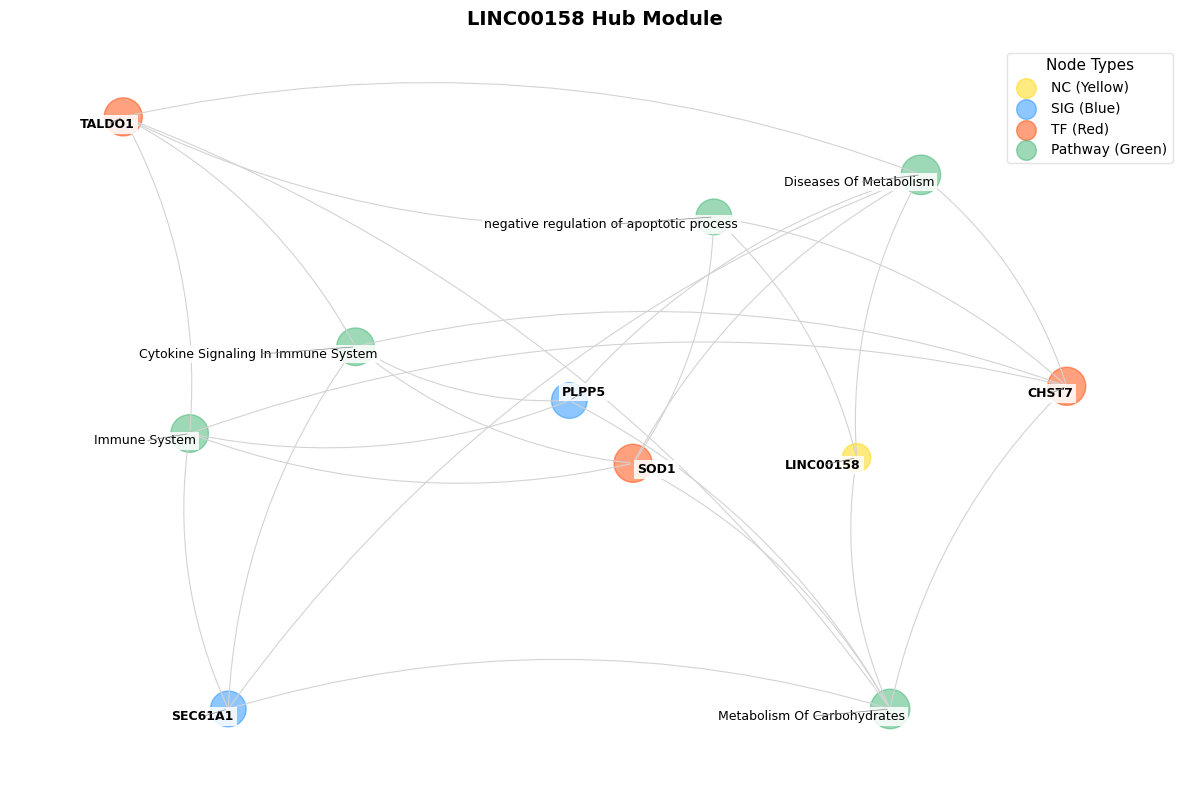

In [41]:
import re
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

# =====================================================================
# 1. DEFINITIONS & DATA LOADING
# =====================================================================
# Complete cluster 3 list including genes, non-coding RNAs, and biological pathways
cluster_3_elements = [
    'CHST7', 'Cytokine Signaling In Immune System', 'Diseases Of Metabolism', 
    'Immune System', 'LINC00158', 'Metabolism Of Carbohydrates', 'PLPP5', 
    'SEC61A1', 'SOD1', 'TALDO1', 'negative regulation of apoptotic process'
]

# Explicitly categorize nodes based on biological functions
nc_nodes = {'LINC00158'}                                     # Long Intergenic Non-Coding RNA (Yellow)
sig_nodes = {'PLPP5', 'SEC61A1'}                            # Membrane Transporters and Structural Adapters (Blue)
tf_nodes = {'CHST7', 'SOD1', 'TALDO1'}                      # Active Metabolic Enzymes / Homeostasis Regulators (Red)

top_n_pathways = 25

def clean_label(label):
    """Remove pathway IDs (Reactome, WikiPathways, GO)."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# =====================================================================
# 2. GRAPH CONSTRUCTION
# =====================================================================
F_filtered = nx.Graph()

for item in cluster_3_elements:
    if item in nc_nodes:
        F_filtered.add_node(item, Type='NC')
    elif item in sig_nodes:
        F_filtered.add_node(item, Type='SIG')
    elif item in tf_nodes:
        F_filtered.add_node(item, Type='TF')
    else:
        F_filtered.add_node(item, Type='Pathway')

# Generate contextual connections between genes and pathways based on Cluster 3 homeostatic functions
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in ['TF', 'NC', 'SIG']:
        for target in F_filtered.nodes():
            if F_filtered.nodes[target]['Type'] == 'Pathway':
                target_lower = target.lower()
                
                # Map enzymatic/regulatory machinery to metabolism, immune processing, or cell survival
                if node in ['CHST7', 'TALDO1', 'SOD1'] and any(k in target_lower for k in ["metabolism", "immune", "apoptotic"]):
                    F_filtered.add_edge(node, target)
                # Map membrane translocators and signaling machinery to transport/immune axes
                elif node in ['SEC61A1', 'PLPP5'] and any(k in target_lower for k in ["immune", "cytokine", "metabolism"]):
                    F_filtered.add_edge(node, target)
                # Group non-coding RNAs with overarching baseline regulatory functions
                elif node == 'LINC00158' and any(k in target_lower for k in ["metabolism", "apoptotic"]):
                    F_filtered.add_edge(node, target)

# =====================================================================
# 3. REMOVE UNLINKED (ISOLATED) NODES
# =====================================================================
unlinked_nodes = list(nx.isolates(F_filtered))
F_filtered.remove_nodes_from(unlinked_nodes)

# =====================================================================
# 4. CENTRALITY CALCULATION
# =====================================================================
k_value = min(10, len(F_filtered.nodes()))
centrality = nx.betweenness_centrality(F_filtered, k=k_value, endpoints=True)

pathway_centrality = {
    n: centrality[n]
    for n in F_filtered.nodes()
    if F_filtered.nodes[n]['Type'] == 'Pathway'
}
top_pathways = sorted(pathway_centrality, key=pathway_centrality.get, reverse=True)[:top_n_pathways]

# =====================================================================
# 5. CLEAN LABELS
# =====================================================================
cleaned_labels = {}
for node in F_filtered.nodes():
    cleaned_labels[node] = clean_label(node)

# =====================================================================
# 6. SUB-COMMUNITY DETECTION INSIDE CLUSTER 3
# =====================================================================
try:
    import community as community_louvain
    partition = community_louvain.best_partition(F_filtered)
except Exception:
    communities_list = list(nx.algorithms.community.greedy_modularity_communities(F_filtered))
    partition = {}
    for i, comm in enumerate(communities_list):
        for node in comm:
            partition[node] = i

# =====================================================================
# 7. LAYOUT GENERATION (Tighter space compression)
# =====================================================================
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

# Compact radius to pull modules tightly together
radius = 1.0  
num_comms = len(communities)
angle_step = 2 * np.pi / max(num_comms, 1)
comm_centroids = {
    comm_id: (radius * np.cos(i * angle_step), radius * np.sin(i * angle_step))
    for i, comm_id in enumerate(communities)
}

pos = {}
for comm_id, nodes in communities.items():
    subgraph = F_filtered.subgraph(nodes)
    # Tight spring constant layout
    sub_pos = nx.spring_layout(subgraph, k=0.22, seed=1450)
    cx, cy = comm_centroids[comm_id]
    for n, (x, y) in sub_pos.items():
        pos[n] = (x + cx, y + cy)

# =====================================================================
# 8. NODE COLORING & SIZING
# =====================================================================
node_color = []
for n in F_filtered.nodes():
    node_type = F_filtered.nodes[n]['Type']
    if node_type == 'NC':
        node_color.append('#FFD700')       # Yellow
    elif node_type == 'SIG':
        node_color.append('#1E90FF')      # Blue
    elif node_type == 'TF':
        node_color.append('#FF4500')       # Red
    elif node_type == 'Pathway':
        node_color.append('#3CB371')      # Green

# Balanced node sizes optimized for compressed layout footprints
node_size = [centrality[v] * 2500 + 120 for v in F_filtered.nodes()]

# =====================================================================
# 9. DRAW GRAPH OBJECTS
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Alpha set to 0.5 for uniform 50% transparency across all nodes
nx.draw_networkx_nodes(
    F_filtered,
    pos=pos,
    node_color=node_color,
    node_size=node_size,
    alpha=0.5,
    ax=ax
)

for u, v in F_filtered.edges():
    ax.annotate(
        '',
        xy=pos[v], xycoords='data',
        xytext=pos[u], textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='#D3D3D3',
            lw=0.8,
            connectionstyle='arc3,rad=0.15'
        )
    )

# =====================================================================
# 10. ADD TEXT BOX LABELS
# =====================================================================
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    node_type = F_filtered.nodes[node]['Type']
    
    text = ax.text(
        x, y, label,
        fontsize=9.0, color='black',
        ha='center', va='center',
        fontweight='semibold' if node_type in ['NC', 'SIG', 'TF'] else 'normal',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2.0)
    )
    texts.append(text)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5),
    expand_points=(1.4, 1.4),
    force_points=0.8,
    force_text=0.8,
    ax=ax
)

# =====================================================================
# 11. ADD VISUAL LEGEND
# =====================================================================
ax.scatter([], [], c='#FFD700', alpha=0.5, s=200, label='NC (Yellow)')
ax.scatter([], [], c='#1E90FF', alpha=0.5, s=200, label='SIG (Blue)')
ax.scatter([], [], c='#FF4500', alpha=0.5, s=200, label='TF (Red)')
ax.scatter([], [], c='#3CB371', alpha=0.5, s=200, label='Pathway (Green)')

ax.legend(
    title="Node Types", 
    title_fontsize='11', 
    fontsize='10', 
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    edgecolor='#E0E0E0',
    framealpha=0.9
)

# =====================================================================
# 12. FINALIZE AND DISPLAY
# =====================================================================
plt.title("LINC00158 Hub Module", fontsize=14, fontweight='bold', pad=15)
ax.margins(0.12, 0.12)
fig.tight_layout()
plt.axis("off")

plt.savefig("../../figures/LINC00158_submodule.png", dpi=300, bbox_inches='tight')
plt.show()
